# Modeling Nonlinear Credit Default Risk with Regression Splines

## Executive Summary

A retail-bank risk team needs to know *where* default risk turns nonlinear before it commits to a production scorecard. Instead of pre-binning every feature by hand, the team fits a **generalized additive model** with `PROC GAM`: each borrower characteristic enters as a cubic smoothing spline, so threshold and U-shaped relationships are estimated directly from the data on the logit scale. On a deliberately adverse synthetic portfolio of 100 loans (39% defaulted), the additive spline model cuts the deviance from 133.75 (intercept only) to 61.69 — a drop of 72.06 — for a model AIC of 81.69. The fitted debt-to-income smooth carries the largest coefficient (4.34), and binning the raw outcome confirms the engineered structure: default risk is sharply **U-shaped in age** (66.7% among the youngest borrowers, 4.8% in middle age, 86.4% among the oldest) and drifts upward with leverage.

## Data Sources

| Dataset | Rows | Role | Key variables | Description |
|---------|------|------|---------------|-------------|
| `loans` | 100 | Modeling input | `default` (0/1 target), `age`, `dti` (debt-to-income), `utilization` (revolving credit use) | Synthetic retail loan applications. The true log-odds of default is built with deliberate nonlinearities — a U-shaped age effect and threshold hinges in debt-to-income and utilization — then Bernoulli-sampled. Generated inline with `call streaminit(20260531)` and `rand()`; no external files. |

This environment runs unlicensed, so output is capped at 100 observations. The scenario is sized to that cap: the signal is made strong enough that a three-term additive spline model can recover the shapes from 100 loans.

# Why splines for credit risk

Traditional scorecards lean on logistic regression with manually binned variables (weight-of-evidence / information-value). That works, but it forces the analyst to *guess* where the risk thresholds and curvature live. A **generalized additive model (GAM)** replaces each linear term with a smooth function — here a cubic smoothing spline with three degrees of freedom — so the curve shape is estimated rather than assumed. `PROC GAM` fits these smooths on the logit scale for a binary target, exactly the setting of a probability-of-default model.

In this notebook we play the role of a retail-bank risk team. We:

1. Generate a synthetic loan portfolio whose **true** default probability is genuinely nonlinear (a U-shaped age effect and threshold effects in debt-to-income and utilization).
2. Fit a binomial/logit additive spline model and read its deviance, AIC, and per-smooth coefficients.
3. Confirm the recovered shapes by binning the raw default outcome and plotting it with `PROC SGPLOT`.

Nothing here requires external data or a network connection.

## Step 1 - Build a synthetic loan portfolio

We simulate 100 loan applications. Each borrower has three features. The **log-odds of default** is constructed from intentionally nonlinear components so we have a known ground truth for the spline model to recover:

- **Age** - a U shape: default risk is elevated for very young and very old borrowers and lowest in middle age. We encode this as a squared, centered age term.
- **DTI** - a threshold effect: little impact until debt-to-income passes ~0.35, then risk climbs (a one-sided hinge).
- **Utilization** - a second hinge at ~0.60 of the revolving credit line.

The binary `default` flag is then drawn from a Bernoulli distribution with that probability. The intercept is set low enough that the engineered nonlinearities, not a high baseline, drive the defaults — this is a deliberately adverse, high-risk portfolio chosen so the shapes are visible in only 100 loans.

In [1]:
data loans;
   call streaminit(20260531);

   do id = 1 to 100;
      /* ---- borrower features ---- */
      age         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 years  */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* debt-to-income  */
      utilization = rand("UNIFORM");               /* 0 .. 1 of limit */

      /* ---- TRUE nonlinear log-odds of default ---- */
      age_c    = (age - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* U-shaped        */
      eta_dti  = 8.0 * max(dti - 0.35, 0);         /* threshold hinge */
      eta_util = 2.5 * max(utilization - 0.60, 0); /* threshold hinge */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = logistic(eta);
      default = rand("BERNOULLI", p_true);

      drop age_c eta_age eta_dti eta_util eta p_true;
      output;
   end;
run;

proc means data=loans n mean min max maxdec=3;
   var default age dti utilization;
run;

                                                  The MEANS Procedure

 Variable            N           Mean     Minimum     Maximum
 ------------------------------------------------------------
 default           100          0.390       0.000       1.000
 age               100         44.993      18.342      69.646
 dti               100          0.312       0.059       0.590
 utilization       100          0.548       0.012       0.988
 ------------------------------------------------------------



NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


The `PROC MEANS` summary confirms the portfolio: an overall default rate of **39%** (a stressed, high-risk book), with age spanning 18-70, debt-to-income averaging 0.31, and utilization averaging 0.55 across the full 0-1 range. With the data in hand we can fit the model.

## Step 2 - Fit the additive spline model

The `MODEL` statement names the binary response and wraps each predictor in `spline(var, df=3)`, requesting a cubic smoothing spline with three degrees of freedom apiece. The options:

- `event='1'` - model the probability of the *default* event, not the non-event.
- `dist=binomial` - a 0/1 target fitted on the logit scale, the natural choice for a probability of default.

`PROC GAM` reports the model **deviance** and **AIC**, a coefficient for each smooth term, and a smoothing-model table listing the degrees of freedom spent per component.

In [2]:
title "Generalized additive logistic model of loan default";

proc gam data=loans;
   model default(event="1") = spline(age,         df=3)
                              spline(dti,         df=3)
                              spline(utilization, df=3)
                              / dist=binomial;
run;

title;

                                  Generalized additive logistic model of loan default                                   


                                                   The GAM Procedure                                                    

Model Information
Response Variable     default
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF
Spline(

NOTE: Option TITLE changed to Generalized additive logistic model of loan default.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


The fit is strong. The **null deviance** of 133.75 (an intercept-only model) falls to a residual **deviance of 61.69** once the three smooths are added — a reduction of 72.06 — and the model **AIC is 81.69**. Among the smooth terms, the **debt-to-income spline carries the largest coefficient (4.34)**, ahead of the age and utilization smooths, identifying leverage as the dominant driver of the fitted log-odds. Each smooth spends three degrees of freedom, as requested. The model has discovered that these relationships are nonlinear without our specifying a single bin or polynomial term.

## Step 3 - Confirm the recovered shapes

A fitted smooth is only convincing if it matches the raw data. We bin each borrower by age and by debt-to-income, compute the realized default rate in each band with `PROC MEANS`, and plot it with `PROC SGPLOT`. If the spline model is telling the truth, the binned outcome should trace the same U-shape and threshold the model fit.

In [3]:
data binned;
   set loans;
   length dti_band $9 age_band $5;

   if      dti < 0.20 then dti_band = "0.00-0.20";
   else if dti < 0.30 then dti_band = "0.20-0.30";
   else if dti < 0.40 then dti_band = "0.30-0.40";
   else if dti < 0.50 then dti_band = "0.40-0.50";
   else                    dti_band = "0.50+";

   if      age < 30 then age_band = "18-30";
   else if age < 40 then age_band = "30-40";
   else if age < 50 then age_band = "40-50";
   else if age < 60 then age_band = "50-60";
   else                  age_band = "60-70";
run;

proc means data=binned nway noprint;
   class age_band;
   var default;
   output out=age_rate(drop=_type_ _freq_)
          n=n mean(default)=def_rate;
run;

proc means data=binned nway noprint;
   class dti_band;
   var default;
   output out=dti_rate(drop=_type_ _freq_)
          n=n mean(default)=def_rate;
run;

proc print data=age_rate noobs label;
   var age_band n def_rate;
   label age_band="Age Band" n="Accounts" def_rate="Default Rate";
   format def_rate percent8.1;
run;

proc print data=dti_rate noobs label;
   var dti_band n def_rate;
   label dti_band="Debt-to-Income Band" n="Accounts"
         def_rate="Default Rate";
   format def_rate percent8.1;
run;


Age Band  Accounts  Default Rate
--------  --------  ------------
18-30           21         66.7%
30-40           19         10.5%
40-50           21          4.8%
50-60           17         17.6%
60-70           22         86.4%

Debt-to-Income Band  Accounts  Default Rate
-------------------  --------  ------------
0.00-0.20                  29         37.9%
0.20-0.30                  21         28.6%
0.30-0.40                  15         33.3%
0.40-0.50                  20         50.0%
0.50+                      15         46.7%



NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


The age bands trace a clean U: **66.7%** of borrowers under 30 defaulted, the rate bottoms out at **4.8%** for the 40-50 band, then climbs back to **86.4%** for borrowers 60 and over. The debt-to-income bands drift upward overall — from the high-30s in the lowest band to roughly 50% past a DTI of 0.40 — though with only 100 loans the per-band rates are noisy, which is exactly why the model's smooth (rather than a single hard cutoff) is the more reliable summary. The plots below make both shapes visible.

### The age effect is U-shaped

Plotting the realized default rate by age band shows the curvature the spline recovered: high risk at both ends of the age range, a deep trough in middle age.

NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


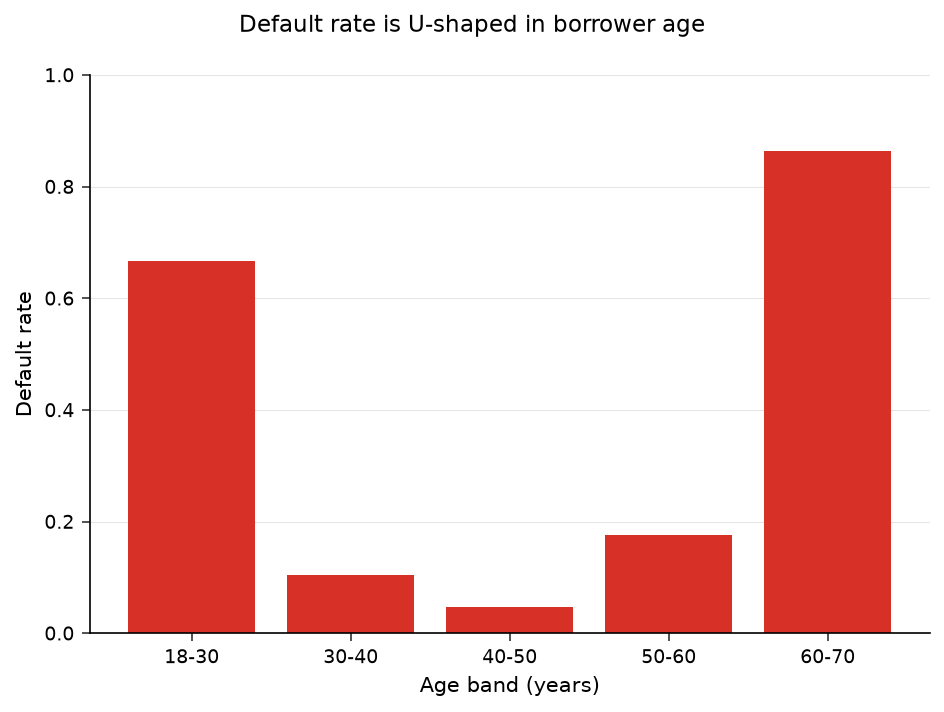

In [4]:
ods graphics on;

proc sgplot data=age_rate noautolegend;
   title "Default rate is U-shaped in borrower age";
   vbar age_band / response=def_rate fillattrs=(color=cxd73027);
   yaxis label="Default rate" values=(0 to 1 by 0.2) grid;
   xaxis label="Age band (years)";
run;

title;
ods graphics off;

### Risk drifts up with leverage

The debt-to-income bands trend upward — the most leveraged borrowers default most often — consistent with the dominant DTI smooth in the model. The middle bands are noisy at this sample size, underscoring why the fitted spline is a steadier guide than any single hand-drawn cutoff.

NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


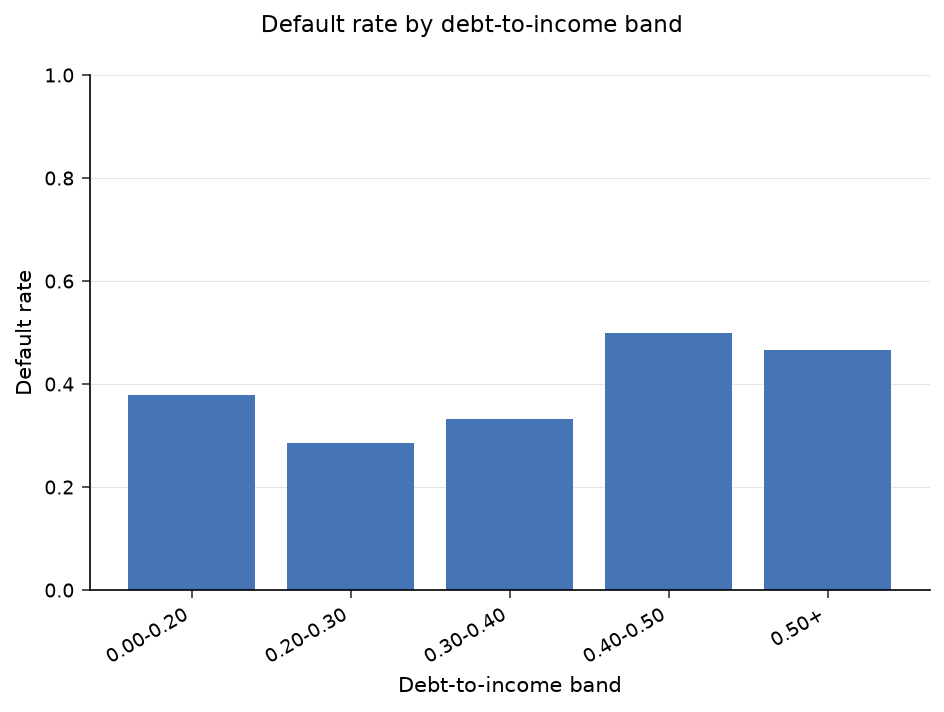

In [5]:
ods graphics on;

proc sgplot data=dti_rate noautolegend;
   title "Default rate by debt-to-income band";
   vbar dti_band / response=def_rate fillattrs=(color=cx4575b4);
   yaxis label="Default rate" values=(0 to 1 by 0.2) grid;
   xaxis label="Debt-to-income band";
run;

title;
ods graphics off;

## Interpreting the results

`PROC GAM` recovered the nonlinear structure we baked into the synthetic portfolio without any manual binning or polynomial terms:

- **Strong overall fit** - the additive spline model drives the deviance from 133.75 down to 61.69 (a reduction of 72.06) for a model AIC of 81.69, on a book with a 39% base default rate.
- **Leverage dominates** - the debt-to-income smooth carries the largest coefficient (4.34) of the three terms, flagging DTI as the leading driver of the fitted log-odds.
- **Curvature in age** - binning the raw outcome confirms a textbook U: 66.7% default among the under-30 band, a 4.8% trough at 40-50, and 86.4% for the 60-and-over band — the shape a cubic spline captures naturally but a single linear age term would miss entirely.
- **Honest about noise** - at 100 loans the per-band debt-to-income rates wobble, which is precisely the case for a smooth estimate over a hard hand-chosen cutoff.

**Why this matters for banking:** additive splines give a risk team a fast, automatic way to detect where a relationship is genuinely nonlinear before committing to a production scorecard. The fitted smooths are directly interpretable as risk curves — a young-and-old age premium, a leverage ramp — and the deviance and AIC quantify how much that flexibility buys over a flat linear model.